This is a rewrite based on [2 - Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation - legacy](https://github.com/bentrevett/pytorch-seq2seq/blob/rewrite/legacy/2%20-%20Learning%20Phrase%20Representations%20using%20RNN%20Encoder-Decoder%20for%20Statistical%20Machine%20Translation.ipynb)
and [non-legacy version](https://github.com/bentrevett/pytorch-seq2seq/blob/rewrite/2%20-%20Learning%20Phrase%20Representations%20using%20RNN%20Encoder-Decoder%20for%20Statistical%20Machine%20Translation.ipynb)

This only summarizes the content above in a way that I can easily refer or revise. Full information, please refer to the given link.


**This note still get stuck at train_model but script version running native works just fine. I will just move on**


    # Output:
    # The model has 14,219,781 trainable parameters
    # | Test Loss: 3.507 | Test PPL:  33.357 |
    # {'bleu': 0.22014749491927466,
    # 'precisions': [0.5587299181570172, 0.2866513611020007, 0.1590746695248303, 0.09219301686936053],
    # 'brevity_penalty': 1.0,
    # 'length_ratio': 1.0105682340327768,
    # 'translation_length': 13196, 'reference_length': 13058}



The implementation has no difference to 2_Seq2Seq except changes in `Decoder` implementation where near `Attention` concept is brought to surface. Instead of `Attention`, the output layer of `Decoder` is all given `Context Vector` parameters.
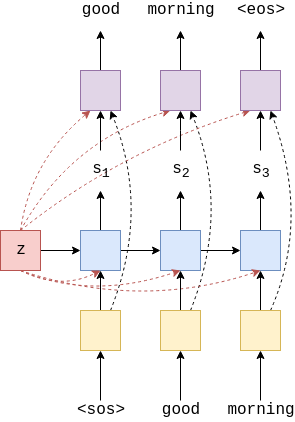

- <u>Hypothetically</u>, the decoder hidden states, st, no longer need to contain information about the source sequence as it is always available as an input.
- Thus, it only needs to contain information about what tokens it has generated so far.
- The addition of yt to the linear layer also means this layer can directly see what the token is without getting information from hidden state.
- <u>This is a hypothesis.</u> But the results indicate that this modification makes improvements.

In [ ]:
!pip install datasets evaluate --upgrade

!python -m spacy download de_core_news_sm
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 64.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 52.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# from torchtext.legacy.datasets import Multi30k
# from torchtext.legacy.data import Field, BucketIterator
import torchtext ; torchtext.disable_torchtext_deprecation_warning()
from torchtext.vocab import build_vocab_from_iterator

import random
import spacy
import numpy as np

import datasets
import evaluate
import tqdm

In [ ]:
SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

Load the data.

In [ ]:
dataset = datasets.load_dataset("bentrevett/multi30k")
train_data, valid_data, test_data = (
    dataset["train"],
    dataset["validation"],
    dataset["test"],
)

In [ ]:
spacy_de = spacy.load('de_core_news_sm')
spacy_en = spacy.load('en_core_web_sm')

Previously we reversed the source (German) sentence, however in the paper we are implementing they don't do this, so neither will we.

In [ ]:
def tokenize_example(example, spacy_en, spacy_de, max_length, lower, sos_token, eos_token):
    en_tokens = [token.text for token in spacy_en.tokenizer(example["en"])][:max_length]
    de_tokens = [token.text for token in spacy_de.tokenizer(example["de"])][:max_length]
    if lower:
        en_tokens = [token.lower() for token in en_tokens]
        de_tokens = [token.lower() for token in de_tokens]
    en_tokens = [sos_token] + en_tokens + [eos_token]
    de_tokens = [sos_token] + de_tokens + [eos_token]
    return {"en_tokens": en_tokens, "de_tokens": de_tokens}

In [ ]:
max_length = 1_000
lower = True
sos_token = "<sos>"
eos_token = "<eos>"

fn_kwargs = {
    "spacy_en": spacy_en,
    "spacy_de": spacy_de,
    "max_length": max_length,
    "lower": lower,
    "sos_token": sos_token,
    "eos_token": eos_token,
}

train_data = train_data.map(tokenize_example, fn_kwargs=fn_kwargs)
valid_data = valid_data.map(tokenize_example, fn_kwargs=fn_kwargs)
test_data = test_data.map(tokenize_example, fn_kwargs=fn_kwargs)

Map:   0%|          | 0/1014 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
min_freq = 2
unk_token = "<unk>"
pad_token = "<pad>"

special_tokens = [
    unk_token,
    pad_token,
    sos_token,
    eos_token,
]

en_vocab = build_vocab_from_iterator(
    train_data["en_tokens"],
    min_freq=min_freq,
    specials=special_tokens,
)

de_vocab = torchtext.vocab.build_vocab_from_iterator(
    train_data["de_tokens"],
    min_freq=min_freq,
    specials=special_tokens,
)

In [ ]:
assert en_vocab[unk_token] == de_vocab[unk_token]
assert en_vocab[pad_token] == de_vocab[pad_token]

unk_index = en_vocab[unk_token]
pad_index = en_vocab[pad_token]

en_vocab.set_default_index(unk_index)
de_vocab.set_default_index(unk_index)

In [ ]:
def numericalize_example(example, en_vocab, de_vocab):
    en_ids = en_vocab.lookup_indices(example["en_tokens"])
    de_ids = de_vocab.lookup_indices(example["de_tokens"])
    return {"en_ids": en_ids, "de_ids": de_ids}

In [ ]:
fn_kwargs = {"en_vocab": en_vocab, "de_vocab": de_vocab}

train_data = train_data.map(numericalize_example, fn_kwargs=fn_kwargs)
valid_data = valid_data.map(numericalize_example, fn_kwargs=fn_kwargs)
test_data = test_data.map(numericalize_example, fn_kwargs=fn_kwargs)

Map:   0%|          | 0/29000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1014 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
data_type = "torch"
format_columns = ["en_ids", "de_ids"]

train_data = train_data.with_format(
    type=data_type, columns=format_columns, output_all_columns=True
)

valid_data = valid_data.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True,
)

test_data = test_data.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True,
)

In [ ]:
def get_collate_fn(pad_index):
    def collate_fn(batch):
        batch_en_ids = [example["en_ids"] for example in batch]
        batch_de_ids = [example["de_ids"] for example in batch]
        batch_en_ids = nn.utils.rnn.pad_sequence(batch_en_ids, padding_value=pad_index)
        batch_de_ids = nn.utils.rnn.pad_sequence(batch_de_ids, padding_value=pad_index)
        batch = {
            "en_ids": batch_en_ids,
            "de_ids": batch_de_ids,
        }
        return batch

    return collate_fn

In [ ]:
def get_data_loader(dataset, batch_size, pad_index, shuffle=False):
    collate_fn = get_collate_fn(pad_index)
    data_loader = torch.utils.data.DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        collate_fn=collate_fn,
        shuffle=shuffle,
    )

    return data_loader

In [ ]:
batch_size = 128

train_data_loader = get_data_loader(train_data, batch_size, pad_index, shuffle=True)
valid_data_loader = get_data_loader(valid_data, batch_size, pad_index)
test_data_loader = get_data_loader(test_data, batch_size, pad_index)

## Encoder
will be similar to previous implementation at 2_Seq2Seq_Encoder_Decoder.

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, dropout):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(input_dim, embedding_dim)
        self.rnn = nn.GRU(embedding_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src = [src length, batch size]
        embedded = self.dropout(self.embedding(src))
        # embedded = [src length, batch size, embedding dim]
        outputs, hidden = self.rnn(embedded)  # No cell state in GRU!
        # outputs = [src length, batch size, hidden dim * n directions]
        # hidden = [n layers * n directions, batch size, hidden dim]
        # Outputs are always from the top hidden layer
        return hidden

## Decoder


- With the implementation, we pass d(yt) and z to the Decoder GRU by concatenating them together; input dimensions to the GRU are `emb_dim + hid_dim` (context vector is only `hid_dim`).
- The linear layer, f, only uses the top-layer decoder hidden state.
- We pass embedding of token and context vector,z to the linear layer (purple box in the diagram)
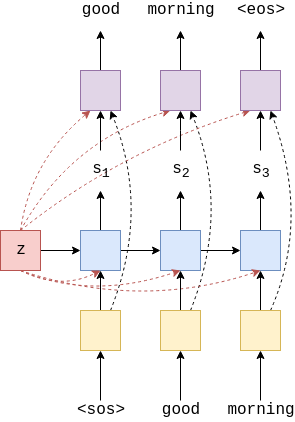

In [ ]:
class Decoder(nn.Module):
    def __init__(self, output_dim, embedding_dim, hidden_dim, dropout):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.embedding = nn.Embedding(output_dim, embedding_dim)
        self.rnn = nn.GRU(embedding_dim + hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(embedding_dim + hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, context):
        # input = [batch size]
        # hidden = [n layers * n directions, batch size, hidden dim]
        # context = [n layers * n directions, batch size, hidden dim]

        #"" n layers and n directions in the decoder will both always be 1, therefore:""
        # hidden = [1, batch size, hidden dim]
        # context = [1, batch size, hidden dim]

        input = input.unsqueeze(0)

        # input = [1, batch size]

        embedded = self.dropout(self.embedding(input))

        # embedded = [1, batch size, embedding dim]

        emb_con = torch.cat((embedded, context), dim=2)

        # emb_con = [1, batch size, embedding dim + hidden dim]

        output, hidden = self.rnn(emb_con, hidden)
        # output = [seq len, batch size, hidden dim * n directions]
        # hidden = [n layers * n directions, batch size, hidden dim]

        # ""seq len, n layers and n directions will always be 1 in this decoder, therefore:""
        # output = [1, batch size, hidden dim]
        # hidden = [1, batch size, hidden dim]
        output = torch.cat(
            (embedded.squeeze(0), hidden.squeeze(0), context.squeeze(0)), dim=1
        )
        # output = [batch size, embedding dim + hidden dim * 2]
        prediction = self.fc_out(output)
        # prediction = [batch size, output dim]
        return prediction, hidden

## Seq2Seq


- Putting the encoder and decoder together, we get:
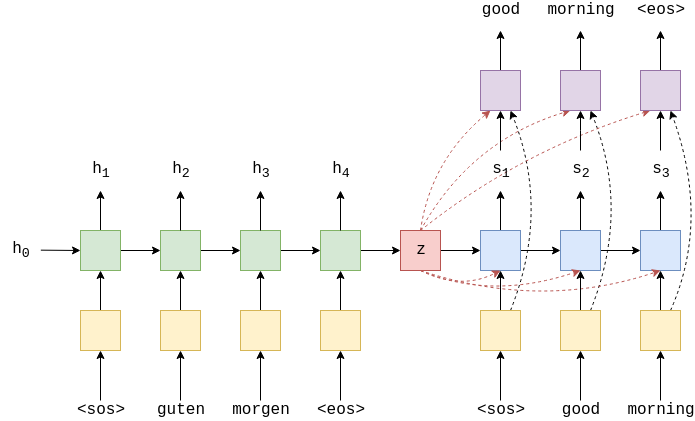

- In this implementation, we need to ensure the hidden dimensions in both encoder and decoder are the same.
- The outputs tensor is created to hold all predictions, Y^
- The source sequence, X, is fed into the encoder to receive a `context vector`
- The initial decoder hidden state is set to be the `context vector`,
- Use a batch of `<sos>` tokens as the first `input`,
- Decode within a loop:
 - Insert input token,yt, previous hidden state, st-1, and context vector, z, into the decoder.
 - Receive a prediction, y^t+1, and a new hidden state, st.
 - Decided if going to `teacher-force` or not (is in training mode -> use teacher-force; not in training mode -> use highest predicted next token)

In [ ]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

        assert encoder.hid_dim == decoder.hid_dim, \
            "Hidden dimensions of encoder and decoder must be equal!"

    def forward(self, src, trg, teacher_forcing_ratio = 0.5):

        #src = [src len, batch size]
        #trg = [trg len, batch size]
        # Teacher_forcing_ratio is probability to use teacher forcing
        # e.g. if teacher_forcing_ratio is 0.75 we use ground-truth inputs 75% of the time

        batch_size = trg.shape[1]
        trg_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim

        # Tensor to store decoder outputs
        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(self.device)

        # Last hidden state of the encoder is the context
        context = self.encoder(src)

        # Context also used as the initial hidden state of the decoder
        hidden = context

        # First input to the decoder is the <sos> tokens
        input = trg[0,:]

        for t in range(1, trg_len):

            # Insert input token embedding, previous hidden state and the context state
            # Receive output tensor (predictions) and new hidden state
            output, hidden = self.decoder(input, hidden, context)

            # Place predictions in a tensor holding predictions for each token
            outputs[t] = output

            #Decide if we are going to use teacher forcing or not
            teacher_force = random.random() < teacher_forcing_ratio

            # Get the highest predicted token from our predictions
            top1 = output.argmax(1)

            # If teacher forcing, use actual next token as next input
            # If not, use predicted token
            input = trg[t] if teacher_force else top1

        return outputs

## Training the model
The rest is similar to previous implementations.

In [ ]:
input_dim = len(de_vocab)
output_dim = len(en_vocab)
encoder_embedding_dim = 256
decoder_embedding_dim = 256
hidden_dim = 512
encoder_dropout = 0.5
decoder_dropout = 0.5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = Encoder(
    input_dim,
    encoder_embedding_dim,
    hidden_dim,
    encoder_dropout,
)

decoder = Decoder(
    output_dim,
    decoder_embedding_dim,
    hidden_dim,
    decoder_dropout,
)

model = Seq2Seq(encoder, decoder, device).to(device)

In [ ]:
def init_weights(m):
    for name, param in m.named_parameters():
        nn.init.normal_(param.data, mean=0, std=0.01)


model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(7853, 256)
    (rnn): GRU(256, 512)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(5893, 256)
    (rnn): GRU(768, 512)
    (fc_out): Linear(in_features=1280, out_features=5893, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"The model has {count_parameters(model):,} trainable parameters")

The model has 14,219,781 trainable parameters


In [ ]:
optimizer = optim.Adam(model.parameters())

In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=pad_index)

In [ ]:
def train_fn(
    model, data_loader, optimizer, criterion, clip, teacher_forcing_ratio, device
):
    model.train()
    epoch_loss = 0
    for i, batch in enumerate(data_loader):
        src = batch["de_ids"].to(device)
        trg = batch["en_ids"].to(device)
        # src = [src length, batch size]
        # trg = [trg length, batch size]
        optimizer.zero_grad()
        output = model(src, trg, teacher_forcing_ratio)
        # output = [trg length, batch size, trg vocab size]
        output_dim = output.shape[-1]
        output = output[1:].view(-1, output_dim)
        # output = [(trg length - 1) * batch size, trg vocab size]
        trg = trg[1:].view(-1)
        # trg = [(trg length - 1) * batch size]
        loss = criterion(output, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(data_loader)

In [ ]:
def evaluate_fn(model, data_loader, criterion, device):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for i, batch in enumerate(data_loader):
            src = batch["de_ids"].to(device)
            trg = batch["en_ids"].to(device)
            # src = [src length, batch size]
            # trg = [trg length, batch size]
            output = model(src, trg, 0)  # turn off teacher forcing
            # output = [trg length, batch size, trg vocab size]
            output_dim = output.shape[-1]
            output = output[1:].view(-1, output_dim)
            # output = [(trg length - 1) * batch size, trg vocab size]
            trg = trg[1:].view(-1)
            # trg = [(trg length - 1) * batch size]
            loss = criterion(output, trg)
            epoch_loss += loss.item()
    return epoch_loss / len(data_loader)

In [ ]:
n_epochs = 10
clip = 1.0
teacher_forcing_ratio = 0.5

best_valid_loss = float("inf")

for epoch in tqdm.tqdm(range(n_epochs)):
    train_loss = train_fn(
        model,
        train_data_loader,
        optimizer,
        criterion,
        clip,
        teacher_forcing_ratio,
        device,
    )
    valid_loss = evaluate_fn(
        model,
        valid_data_loader,
        criterion,
        device,
    )
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "tut1.2-model.pt")
    print(f"\tTrain Loss: {train_loss:7.3f} | Train PPL: {np.exp(train_loss):7.3f}")
    print(f"\tValid Loss: {valid_loss:7.3f} | Valid PPL: {np.exp(valid_loss):7.3f}")

  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
model.load_state_dict(torch.load("tut1.2-model.pt"))

test_loss = evaluate_fn(model, test_data_loader, criterion, device)

print(f"| Test Loss: {test_loss:.3f} | Test PPL: {np.exp(test_loss):7.3f} |")

In [ ]:
def translate_sentence(
    sentence,
    model,
    spacy_en,
    spacy_de,
    en_vocab,
    de_vocab,
    lower,
    sos_token,
    eos_token,
    device,
    max_output_length=25,
):
    model.eval()
    with torch.no_grad():
        if isinstance(sentence, str):
            tokens = [token.text for token in spacy_de.tokenizer(sentence)]
        else:
            tokens = [token for token in sentence]
        if lower:
            tokens = [token.lower() for token in tokens]
        tokens = [sos_token] + tokens + [eos_token]
        ids = de_vocab.lookup_indices(tokens)
        tensor = torch.LongTensor(ids).unsqueeze(-1).to(device)
        context = model.encoder(tensor)
        hidden = context
        inputs = en_vocab.lookup_indices([sos_token])
        for _ in range(max_output_length):
            inputs_tensor = torch.LongTensor([inputs[-1]]).to(device)
            output, hidden = model.decoder(inputs_tensor, hidden, context)
            predicted_token = output.argmax(-1).item()
            inputs.append(predicted_token)
            if predicted_token == en_vocab[eos_token]:
                break
        tokens = en_vocab.lookup_tokens(inputs)
    return tokens

In [ ]:
translations = [
    translate_sentence(
        example["de"],
        model,
        spacy_en,
        spacy_de,
        en_vocab,
        de_vocab,
        lower,
        sos_token,
        eos_token,
        device,
    )
    for example in tqdm.tqdm(test_data)
]

## Bleu scoring

In [ ]:
bleu = evaluate.load("bleu")

In [ ]:
predictions = [" ".join(translation[1:-1]) for translation in translations]

references = [[example["en"]] for example in test_data]

In [ ]:
def get_tokenizer_fn(nlp, lower):
    def tokenizer_fn(s):
        tokens = [token.text for token in nlp.tokenizer(s)]
        if lower:
            tokens = [token.lower() for token in tokens]
        return tokens

    return tokenizer_fn

In [ ]:
tokenizer_fn = get_tokenizer_fn(spacy_en, lower)

In [ ]:
results = bleu.compute(
    predictions=predictions, references=references, tokenizer=tokenizer_fn
)

In [ ]:
results